# kNN-потолок: 1-NN оценка + learning curve (20-NN vs MLP vs boost)

Всё в **одном** признаковом пространстве и **одной** разбивке:

- **φ = конкатенация сжатых эмбеддингов** `[ESM→PCA-19 ‖ GIN→PCA-27]` (46-d),
  PCA обучается только на train, стандартизация блоков по train;
- **split = stratified**, `test_size=0.2`; усреднение по **3 сидам** (сид
  задаёт и разбиение, и инициализацию/подвыборку).

Две части:

1. **1-NN оценка** — accuracy и AUROC ближайшего соседа + граница Cover–Hart
   на достижимую точность (для этого φ).
2. **Learning curve** — как растут метрики методов при увеличении доли
   обучающих данных (~7 точек), усреднённо по 3 сидам. В конце — графики
   пяти метрик (AUROC, AUPRC, F1, MCC, accuracy).

   Методы: **20-NN**, **MLP** (residual-сеть, ~450k), **MLP-simple** (прежний
   слабый узкий MLP, ~31k) и **варианты бустинга** — base/strong конфиг ×
   сжатый(46-d)/полный(1580-d) φ.

In [ ]:
# --- Ячейка 1: setup — данные, φ-сборка, три метода ------------------------
import sys, json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, balanced_accuracy_score,
                             matthews_corrcoef, f1_score)

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from orbind import dataset as D
import xgboost as xgb

DATA  = ROOT / 'data'
CACHE = ROOT / 'notebooks' / 'cache'; CACHE.mkdir(parents=True, exist_ok=True)
_esm_full = D.load_npz_dict(DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean_full.npz')
_curated_recs = set(pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')['receptor'])
ESM = {k: v for k, v in _esm_full.items() if k in _curated_recs}
GIN = D.load_npz_dict(DATA / 'embeddings' / 'molecules' / 'gin_supervised_contextpred.npz')
PAIRS = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
PAIRS = PAIRS[PAIRS['receptor'].isin(ESM) & PAIRS['inchikey'].isin(GIN)].reset_index(drop=True)

K_PROT, K_MOL = 19, 27          # сжатие: ESM->19, GIN->27  (как в pca_rotation_screening)
SPLIT   = 'stratified'
SEEDS   = [42, 7, 123]
print(f'pairs={len(PAIRS)}  proteins={len(ESM)}  molecules={len(GIN)}  φ-dim={K_PROT + K_MOL}')


def pca_transform(emb, train_keys, k):
    """PCA fit на train-ключах, проекция ВСЕХ ключей в k-мерный базис (без утечки)."""
    keys = list(emb.keys())
    X_all = np.stack([emb[x] for x in keys]).astype(np.float64)
    X_tr  = np.stack([emb[x] for x in train_keys]).astype(np.float64)
    mu = X_tr.mean(0, keepdims=True)
    _, _, Vt = np.linalg.svd(X_tr - mu, full_matrices=False)
    kk = min(k, Vt.shape[0])
    proj = (X_all - mu) @ Vt[:kk].T
    if kk < k:
        proj = np.pad(proj, ((0, 0), (0, k - kk)))
    return {x: v.astype(np.float32) for x, v in zip(keys, proj)}


def assemble(seed):
    """stratified split -> PCA(train) -> z-score(train) -> X=[ESM-PCA ‖ GIN-PCA].
    Возвращает X_tr, y_tr, X_te, y_te (46-d)."""
    y = PAIRS['label'].to_numpy(np.int32)
    tr, te = D.split(PAIRS, y.astype(np.float32), kind=SPLIT, test_size=0.2, seed=seed)
    p_tr, p_te = PAIRS[tr].reset_index(drop=True), PAIRS[te].reset_index(drop=True)
    prot = pca_transform(ESM, p_tr['receptor'].unique().tolist(), K_PROT)
    mol  = pca_transform(GIN, p_tr['inchikey'].unique().tolist(), K_MOL)

    def block(p):
        Xp = np.stack([prot[r] for r in p['receptor']]).astype(np.float64)
        Xm = np.stack([mol[m]  for m in p['inchikey']]).astype(np.float64)
        return Xp, Xm

    Xp_tr, Xm_tr = block(p_tr); Xp_te, Xm_te = block(p_te)

    def std(a, b):
        mu, sd = a.mean(0, keepdims=True), a.std(0, keepdims=True) + 1e-6
        return (a - mu) / sd, (b - mu) / sd

    Xp_tr, Xp_te = std(Xp_tr, Xp_te)
    Xm_tr, Xm_te = std(Xm_tr, Xm_te)
    X_tr = np.concatenate([Xp_tr, Xm_tr], 1).astype(np.float32)
    X_te = np.concatenate([Xp_te, Xm_te], 1).astype(np.float32)
    return X_tr, y[tr], X_te, y[te]


def assemble_full(seed):
    """Тот же stratified split (тот же seed => те же пары), но БЕЗ сжатия:
    X = [ESM_mean(1280) ‖ GIN(300)] = 1580-d, z-score по train."""
    y = PAIRS['label'].to_numpy(np.int32)
    tr, te = D.split(PAIRS, y.astype(np.float32), kind=SPLIT, test_size=0.2, seed=seed)
    p_tr, p_te = PAIRS[tr].reset_index(drop=True), PAIRS[te].reset_index(drop=True)

    def block(p):
        Xp = np.stack([ESM[r] for r in p['receptor']]).astype(np.float64)
        Xm = np.stack([GIN[m] for m in p['inchikey']]).astype(np.float64)
        return Xp, Xm

    Xp_tr, Xm_tr = block(p_tr); Xp_te, Xm_te = block(p_te)

    def std(a, b):
        mu, sd = a.mean(0, keepdims=True), a.std(0, keepdims=True) + 1e-6
        return (a - mu) / sd, (b - mu) / sd

    Xp_tr, Xp_te = std(Xp_tr, Xp_te)
    Xm_tr, Xm_te = std(Xm_tr, Xm_te)
    X_tr = np.concatenate([Xp_tr, Xm_tr], 1).astype(np.float32)
    X_te = np.concatenate([Xp_te, Xm_te], 1).astype(np.float32)
    return X_tr, y[tr], X_te, y[te]


def score_metrics(y, score, thr=0.5):
    """5 метрик из вероятностного скора: AUROC, AUPRC (ранжирующие) + accuracy,
    F1, MCC (на пороге 0.5)."""
    pred = (score >= thr).astype(int)
    return {'AUROC': float(roc_auc_score(y, score)),
            'AUPRC': float(average_precision_score(y, score)),
            'accuracy': float(accuracy_score(y, pred)),
            'F1': float(f1_score(y, pred, zero_division=0)),
            'MCC': float(matthews_corrcoef(y, pred))}


# --- методы: каждый возвращает вероятностный скор на test -------------------
class ResBlock(nn.Module):
    def __init__(self, d, p=0.2):
        super().__init__()
        self.l1 = nn.Linear(d, d); self.b1 = nn.BatchNorm1d(d)
        self.l2 = nn.Linear(d, d); self.b2 = nn.BatchNorm1d(d)
        self.dr = nn.Dropout(p)

    def forward(self, x):
        h = torch.nn.functional.gelu(self.b1(self.l1(x)))
        h = self.b2(self.l2(h))
        return torch.nn.functional.gelu(x + self.dr(h))     # residual


class MLPNet(nn.Module):
    """Крупнее и «круче»: stem -> N residual-блоков (GELU/BN/Dropout) -> голова.
    Вход небольшой (46-d) => можем позволить ширину 256 и residual-глубину."""
    def __init__(self, d_in, width=256, blocks=3, p=0.2):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(d_in, width), nn.BatchNorm1d(width),
                                  nn.GELU(), nn.Dropout(p))
        self.blocks = nn.Sequential(*[ResBlock(width, p) for _ in range(blocks)])
        self.head = nn.Sequential(nn.Linear(width, 128), nn.GELU(), nn.Dropout(p),
                                  nn.Linear(128, 64), nn.GELU(), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(1)


MLP_EPOCHS = 60
MLP_TAG = 'resmlp_w256b3_ep60'            # версионирует кэш MLP (архитектура сменилась)

def fit_knn(Xtr, ytr, Xte, k=20):
    nn_ = NearestNeighbors(n_neighbors=k).fit(Xtr)
    _, j = nn_.kneighbors(Xte)
    return ytr[j].mean(1)                                  # доля позитивов среди k соседей

def fit_mlp(Xtr, ytr, Xte, seed=0, epochs=MLP_EPOCHS):
    torch.manual_seed(seed)
    m = MLPNet(Xtr.shape[1])
    opt = torch.optim.Adam(m.parameters(), lr=1.5e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)  # cosine LR
    posw = torch.tensor([(ytr == 0).sum() / max((ytr == 1).sum(), 1)], dtype=torch.float32)
    lossf = nn.BCEWithLogitsLoss(pos_weight=posw)
    Xt = torch.tensor(Xtr); yt = torch.tensor(ytr, dtype=torch.float32); Xv = torch.tensor(Xte)
    n = len(Xtr)
    for _ in range(epochs):
        m.train(); perm = torch.randperm(n)
        for i in range(0, n, 512):
            idx = perm[i:i + 512]; opt.zero_grad()
            lossf(m(Xt[idx]), yt[idx]).backward(); opt.step()
        sch.step()
    m.eval()
    with torch.no_grad():
        return torch.sigmoid(m(Xv)).numpy()

class MLPSimple(nn.Module):
    """Прежний «слабый» MLP: узкий-глубокий, ReLU, без residual/scheduler."""
    def __init__(self, d_in, hidden=(128, 96, 64, 48, 32, 24), p=0.2):
        super().__init__()
        layers, prev = [], d_in
        for u in hidden:
            layers += [nn.Linear(prev, u), nn.BatchNorm1d(u), nn.ReLU(), nn.Dropout(p)]
            prev = u
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


MLP_SIMPLE_EPOCHS = 40
MLP_SIMPLE_TAG = 'simplemlp_w128b6_ep40'

def fit_mlp_simple(Xtr, ytr, Xte, seed=0, epochs=MLP_SIMPLE_EPOCHS):
    torch.manual_seed(seed)
    m = MLPSimple(Xtr.shape[1])
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)   # без scheduler
    posw = torch.tensor([(ytr == 0).sum() / max((ytr == 1).sum(), 1)], dtype=torch.float32)
    lossf = nn.BCEWithLogitsLoss(pos_weight=posw)
    Xt = torch.tensor(Xtr); yt = torch.tensor(ytr, dtype=torch.float32); Xv = torch.tensor(Xte)
    n = len(Xtr)
    for _ in range(epochs):
        m.train(); perm = torch.randperm(n)
        for i in range(0, n, 512):
            idx = perm[i:i + 512]; opt.zero_grad()
            lossf(m(Xt[idx]), yt[idx]).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return torch.sigmoid(m(Xv)).numpy()

def fit_boost(Xtr, ytr, Xte, params, seed=42):
    spw = float((ytr == 0).sum() / max((ytr == 1).sum(), 1))
    clf = xgb.XGBClassifier(**params, scale_pos_weight=spw,
                            eval_metric='aucpr', n_jobs=-1, random_state=seed)
    clf.fit(Xtr, ytr.astype(np.float32))
    return clf.predict_proba(Xte)[:, 1]

# два конфига XGBoost: честный baseline (как orbind.baselines.train_boost) и
# усиленный (глубже/больше деревьев/ниже lr + L2) — вход небольшой, можно.
BASE_BOOST   = dict(n_estimators=400,  max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, tree_method='hist')
STRONG_BOOST = dict(n_estimators=1200, max_depth=8, learning_rate=0.03,
                    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                    reg_lambda=2.0, tree_method='hist')

# все варианты boost: (пространство, параметры, тег для кэша)
BOOST_VARIANTS = {
    'boost':              ('compressed', BASE_BOOST,   'base'),      # 46-d, ~2с/фит
    'boost-strong':       ('compressed', STRONG_BOOST, 'strong'),    # 46-d, ~7с/фит
    'boost-full':         ('full',       BASE_BOOST,   'base'),      # 1580-d, ~75с/фит
    # 'boost-full-strong': ('full',      STRONG_BOOST, 'strong'),    # 1580-d, ~5мин/фит (~1.5ч свип) — раскомментируй если нужен
}
METHODS_NN = {'20-NN': fit_knn, 'MLP': fit_mlp, 'MLP-simple': fit_mlp_simple}
print('NN-методы:', list(METHODS_NN), '| boost-варианты:', list(BOOST_VARIANTS))

## 1. Оценка 1-NN: accuracy, AUROC и граница Cover–Hart

Ближайший сосед (`k=1`) в φ — предскажи метку единственного ближайшего
train-соседа. Считаем на полном train каждого из 3 сидов:

- **accuracy** и **balanced accuracy** (среднее recall по классам — честнее
  при дисбалансе ~8% позитивов);
- **AUROC** жёсткого 1-NN — у бинарного предсказания нет градаций, поэтому он
  вырождается ровно в balanced accuracy (показываем для полноты);
- **Cover–Hart ceiling** — `Acc* ≤ (1+√(1−2·R_NN))/2`: верхняя (асимптотич.)
  граница точности любой модели на этом φ, из ошибки 1-NN `R_NN`.

In [ ]:
# --- Ячейка 2: 1-NN оценка (accuracy / AUROC / Cover-Hart), среднее по сидам
def nn1_diag(Xtr, ytr, Xte, yte):
    nn_ = NearestNeighbors(n_neighbors=1).fit(Xtr)
    _, j = nn_.kneighbors(Xte)
    pred = ytr[j[:, 0]]
    R = float((pred != yte).mean())
    ceil = (1 + np.sqrt(max(1 - 2 * R, 0))) / 2
    return {'accuracy': accuracy_score(yte, pred),
            'bal_accuracy': balanced_accuracy_score(yte, pred),
            'AUROC': roc_auc_score(yte, pred),          # = bal_accuracy (жёсткий классиф.)
            'R_NN': R, 'acc_ceiling(Cover-Hart)': ceil}

rows = []
for seed in SEEDS:
    Xtr, ytr, Xte, yte = assemble(seed)
    rows.append(nn1_diag(Xtr, ytr, Xte, yte))
D1 = pd.DataFrame(rows, index=[f'seed{s}' for s in SEEDS])

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('1-NN на φ = [ESM-PCA19 ‖ GIN-PCA27], stratified:\n')
display(D1)
print('\nсреднее ± std по сидам:')
for c in D1.columns:
    print(f'  {c:<26} {D1[c].mean():.4f} ± {D1[c].std():.4f}')

1-NN на φ = [ESM-PCA19 ‖ GIN-PCA27], stratified:



,accuracy,bal_accuracy,AUROC,R_NN,acc_ceiling(Cover-Hart)
seed42,0.8971,0.6724,0.6724,0.1029,0.9456
seed7,0.8880,0.6467,0.6467,0.1120,0.9405
seed123,0.8981,0.6626,0.6626,0.1019,0.9461



среднее ± std по сидам:
  accuracy                   0.8944 ± 0.0056
  bal_accuracy               0.6606 ± 0.0129
  AUROC                      0.6606 ± 0.0129
  R_NN                       0.1056 ± 0.0056
  acc_ceiling(Cover-Hart)    0.9441 ± 0.0031


## 2. Learning curve: 20-NN vs MLP vs boost

Фиксируем test (20%), обучаем каждый метод на растущей **доле train-пула**
(~7 точек), меряем на одном и том же тесте. Всё усредняем по 3 сидам
(усы = ±std). Метрики: **AUROC**, **AUPRC**, **accuracy@0.5**.

Результаты кэшируются на диск (`knn_ceiling_learning_curve.json`) — повторный
запуск мгновенный. Полный прогон с нуля ≈ 4–5 мин на CPU (доминирует MLP).

In [ ]:
# --- Ячейка 3: прогон learning curve на СЖАТОМ φ (кэшируется) --------------
FRACS = [0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 1.00]     # ~7 точек доли train
CFILE = CACHE / 'knn_ceiling_learning_curve_v2.json'   # v2: + F1/MCC
_cache = json.loads(CFILE.read_text()) if CFILE.exists() else {}
def _save(): CFILE.write_text(json.dumps(_cache, indent=1))
FORCE = False

def subsample(ytr, frac, seed):
    if frac >= 1.0:
        return np.arange(len(ytr))
    idx, _ = train_test_split(np.arange(len(ytr)), train_size=frac,
                              stratify=ytr, random_state=seed)
    return idx

MLP_TAGS = {'MLP': f'|{MLP_TAG}', 'MLP-simple': f'|{MLP_SIMPLE_TAG}'}   # версия архитектуры

rows = []
for seed in SEEDS:
    Xtr = ytr = Xte = yte = None                        # ленивая сборка (если всё в кэше)
    for frac in FRACS:
        for name, fn in METHODS_NN.items():
            key = f'PCA{K_PROT}+{K_MOL}|s{seed}|f{frac:.2f}|{name}{MLP_TAGS.get(name, "")}'
            if key in _cache and not FORCE:
                rows.append(_cache[key]); continue
            if Xtr is None:
                Xtr, ytr, Xte, yte = assemble(seed)
            idx = subsample(ytr, frac, seed)
            Xs, ys = Xtr[idx], ytr[idx]
            t0 = time.time()
            score = fn(Xs, ys, Xte, seed=seed) if name != '20-NN' else fn(Xs, ys, Xte)
            rec = {'seed': seed, 'frac': frac, 'method': name, 'n_tr': int(len(ys)),
                   **score_metrics(yte, score)}
            _cache[key] = rec; _save(); rows.append(rec)
            print(f'  s{seed} f{frac:.2f} {name:<6} n={len(ys):>5} '
                  f"AUROC={rec['AUROC']:.4f} AUPRC={rec['AUPRC']:.4f} ({time.time()-t0:.1f}s)")

RES = pd.DataFrame(rows)
print(f'\nсжатое φ (20-NN+MLP): {len(RES)} точек ({len(FRACS)}×{len(SEEDS)}×{len(METHODS_NN)})')

  s42 f0.10 MLP-simple n= 1710 AUROC=0.7203 AUPRC=0.2523 (1.6s)
  s42 f0.20 MLP-simple n= 3421 AUROC=0.7835 AUPRC=0.3188 (2.9s)
  s42 f0.35 MLP-simple n= 5987 AUROC=0.8093 AUPRC=0.3387 (4.8s)
  s42 f0.65 MLP-simple n=11119 AUROC=0.8354 AUPRC=0.3890 (8.5s)
  s42 f0.80 MLP-simple n=13685 AUROC=0.8436 AUPRC=0.3993 (10.8s)
  s7 f0.10 MLP-simple n= 1710 AUROC=0.7228 AUPRC=0.2720 (1.6s)
  s7 f0.20 MLP-simple n= 3421 AUROC=0.7430 AUPRC=0.2815 (2.7s)
  s7 f0.35 MLP-simple n= 5987 AUROC=0.8022 AUPRC=0.3482 (4.6s)
  s7 f0.50 MLP-simple n= 8553 AUROC=0.8134 AUPRC=0.3952 (6.8s)
  s7 f0.65 MLP-simple n=11119 AUROC=0.8224 AUPRC=0.3977 (8.4s)
  s7 f0.80 MLP-simple n=13685 AUROC=0.8375 AUPRC=0.4166 (10.8s)
  s7 f1.00 MLP-simple n=17107 AUROC=0.8417 AUPRC=0.4278 (13.4s)
  s123 f0.10 MLP-simple n= 1710 AUROC=0.7468 AUPRC=0.2560 (1.6s)
  s123 f0.20 MLP-simple n= 3421 AUROC=0.7821 AUPRC=0.3249 (2.7s)
  s123 f0.35 MLP-simple n= 5987 AUROC=0.8154 AUPRC=0.3900 (4.8s)
  s123 f0.50 MLP-simple n= 8553 AUROC=0.8

### Все варианты бустинга (base/strong × сжатый/полный)

Четыре кривые XGBoost на тех же сидах/долях/тесте:

| вариант | пространство | конфиг |
|---|---|---|
| `boost` | сжатый 46-d | честный baseline (`n=400,d=6,lr=0.1`) |
| `boost-strong` | сжатый 46-d | усиленный (`n=1200,d=8,lr=0.03,L2`) |
| `boost-full` | полный 1580-d | честный baseline |
| `boost-full-strong` | полный 1580-d | усиленный (по умолчанию **выкл**) |

⚠ На полном 1580-d бустинг медленный (в ~34× больше признаков): `boost-full`
≈ 75с/фит (~26 мин свип), `boost-full-strong` ≈ 5 мин/фит (~1.5 ч) — поэтому
он закомментирован в `BOOST_VARIANTS` (setup); включается одной строкой. Всё
кэшируется, повторный прогон мгновенный.

In [ ]:
# --- Ячейка 4: все варианты бустинга (кэшируется отдельными ключами) --------
# Лёгкая по умолчанию: сжатые (46-d) варианты считаются (~1-7с/фит), а тяжёлое
# полное φ (1580-d, ~30-75с/фит) берётся ТОЛЬКО из кэша — отсутствующие точки
# пропускаются. Хочешь досчитать полное φ — поставь COMPUTE_FULL=True (долго).
COMPUTE_FULL = False

_asm = {}                                               # (seed, space) -> (Xtr,ytr,Xte,yte)
def get_space(seed, space):
    k = (seed, space)
    if k not in _asm:
        _asm[k] = assemble(seed) if space == 'compressed' else assemble_full(seed)
    return _asm[k]

rows_boost = []
skipped = 0
for seed in SEEDS:
    for frac in FRACS:
        for vname, (space, params, ptag) in BOOST_VARIANTS.items():
            key = f'{space}|s{seed}|f{frac:.2f}|{vname}|{ptag}'
            if key in _cache and not FORCE:
                rows_boost.append(_cache[key]); continue
            if space == 'full' and not COMPUTE_FULL:
                skipped += 1; continue              # тяжёлое и не в кэше -> пропускаем
            Xtr, ytr, Xte, yte = get_space(seed, space)
            idx = subsample(ytr, frac, seed)
            Xs, ys = Xtr[idx], ytr[idx]
            t0 = time.time()
            score = fit_boost(Xs, ys, Xte, params, seed=seed)
            rec = {'seed': seed, 'frac': frac, 'method': vname, 'n_tr': int(len(ys)),
                   **score_metrics(yte, score)}
            _cache[key] = rec; _save(); rows_boost.append(rec)
            print(f'  s{seed} f{frac:.2f} {vname:<18} n={len(ys):>5} '
                  f"AUROC={rec['AUROC']:.4f} AUPRC={rec['AUPRC']:.4f} ({time.time()-t0:.1f}s)")
    _asm.clear()                                        # освобождаем память между сидами

RES_boost = pd.DataFrame(rows_boost)
if skipped:
    print(f'\n[пропущено тяжёлых full-точек не из кэша: {skipped}] '
          f'-> COMPUTE_FULL=True чтобы досчитать')
print(f'boost: {len(RES_boost)} точек (из кэша/расчёта)')


[пропущено тяжёлых full-точек не из кэша: 18] -> COMPUTE_FULL=True чтобы досчитать
boost: 45 точек (из кэша/расчёта)


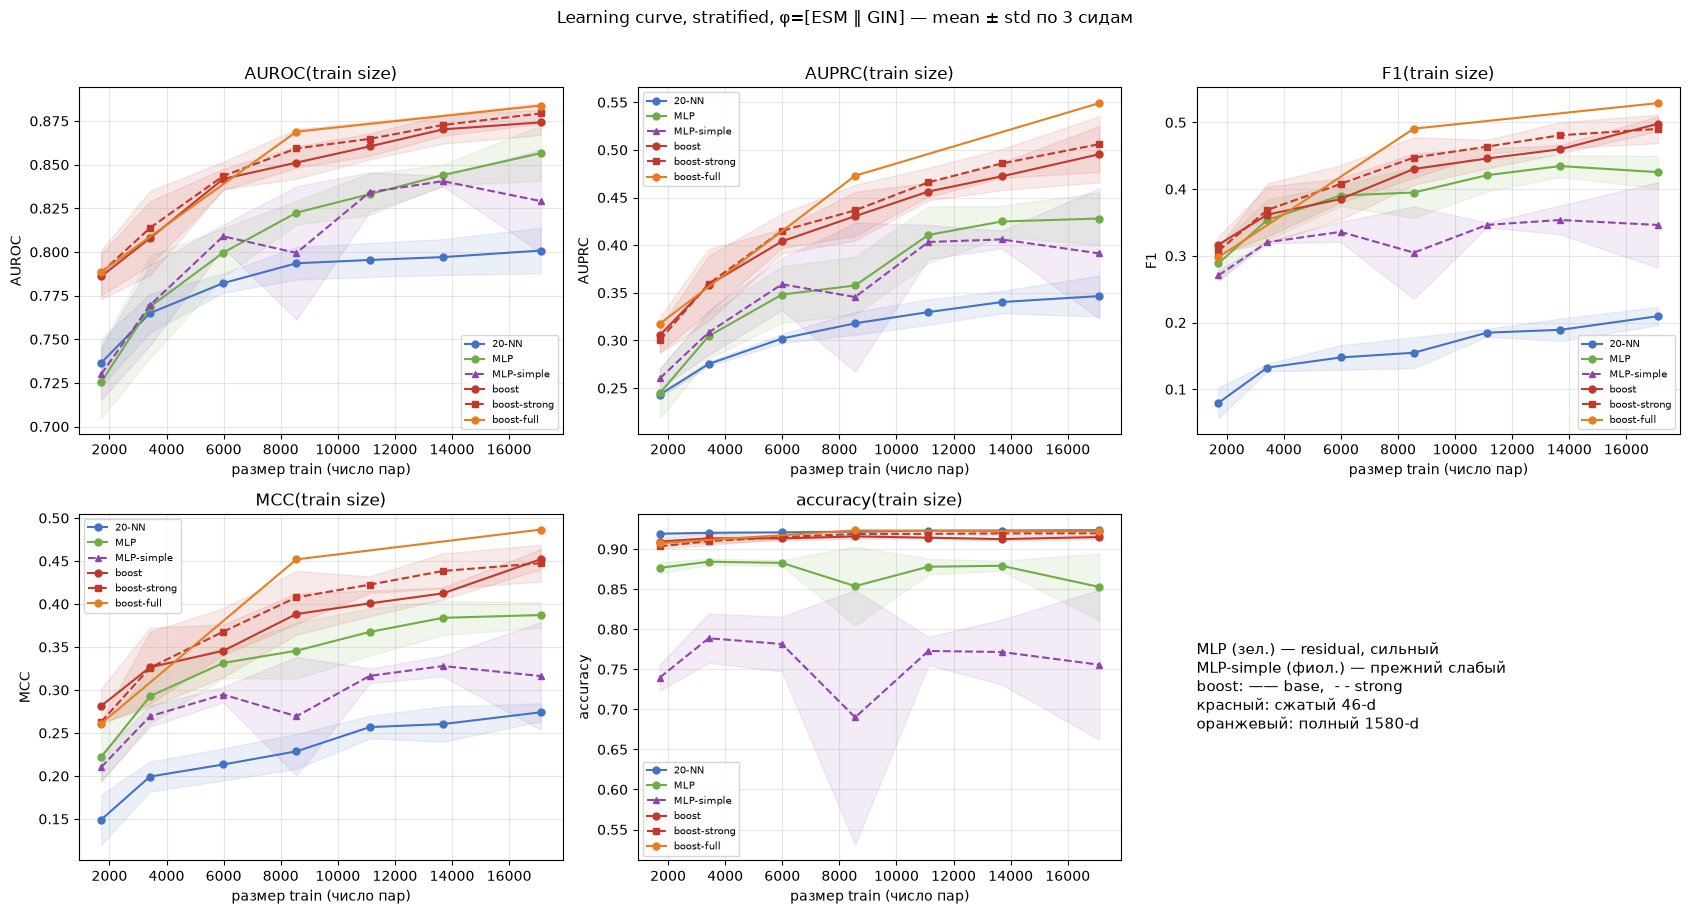

Финал (полный train, mean ± std по сидам):
  20-NN              AUROC=0.801±0.013  AUPRC=0.347±0.021  F1=0.210±0.014  MCC=0.274±0.011  acc=0.924±0.001
  MLP                AUROC=0.857±0.016  AUPRC=0.428±0.027  F1=0.425±0.024  MCC=0.387±0.015  acc=0.853±0.042
  MLP-simple         AUROC=0.829±0.029  AUPRC=0.391±0.068  F1=0.346±0.064  MCC=0.316±0.063  acc=0.756±0.093
  boost              AUROC=0.874±0.007  AUPRC=0.495±0.030  F1=0.498±0.011  MCC=0.452±0.012  acc=0.915±0.002
  boost-strong       AUROC=0.879±0.006  AUPRC=0.506±0.029  F1=0.490±0.021  MCC=0.447±0.021  acc=0.920±0.002
  boost-full         AUROC=0.884±nan  AUPRC=0.549±nan  F1=0.529±nan  MCC=0.487±nan  acc=0.922±nan


In [ ]:
# --- Ячейка 5: графики (все методы, 5 метрик, mean ± std по сидам) ---------
RES_ALL = pd.concat([RES, RES_boost], ignore_index=True)     # идемпотентно

METRICS = ['AUROC', 'AUPRC', 'F1', 'MCC', 'accuracy']
# цвет = пространство/семейство, стиль = конфиг (solid=base, dashed=strong)
STYLE = {
    '20-NN':             ('#4472C4', '-',  'o'),
    'MLP':               ('#70AD47', '-',  'o'),   # residual, сильный
    'MLP-simple':        ('#8E44AD', '--', '^'),   # прежний слабый MLP
    'boost':             ('#C0392B', '-',  'o'),   # 46-d baseline
    'boost-strong':      ('#C0392B', '--', 's'),   # 46-d strong
    'boost-full':        ('#E67E22', '-',  'o'),   # 1580-d baseline
    'boost-full-strong': ('#E67E22', '--', 's'),   # 1580-d strong
}
ORDER = [m for m in STYLE if m in set(RES_ALL['method'])]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()
for ax, metric in zip(axes, METRICS):
    for name in ORDER:
        sub = RES_ALL[RES_ALL['method'] == name]
        col, ls, mk = STYLE[name]
        g = sub.groupby('frac')[metric]
        mean, std = g.mean(), g.std()
        xn = sub.groupby('frac')['n_tr'].mean()               # ось X — число train-пар
        ax.plot(xn, mean, marker=mk, ls=ls, color=col, label=name, ms=5)
        ax.fill_between(xn, mean - std, mean + std, color=col, alpha=0.10)
    ax.set_xlabel('размер train (число пар)'); ax.set_ylabel(metric)
    ax.set_title(f'{metric}(train size)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
axes[-1].axis('off')                                          # 6-я клетка — легенда-заметка
axes[-1].text(0.0, 0.5, 'MLP (зел.) — residual, сильный\nMLP-simple (фиол.) — прежний слабый\n'
              'boost: —— base,  - - strong\nкрасный: сжатый 46-d\nоранжевый: полный 1580-d',
              fontsize=11, va='center')
fig.suptitle('Learning curve, stratified, φ=[ESM ‖ GIN] — mean ± std по 3 сидам', y=1.01)
fig.tight_layout(); plt.show()

print('Финал (полный train, mean ± std по сидам):')
full = RES_ALL[RES_ALL['frac'] == max(FRACS)]
for name in ORDER:
    s = full[full['method'] == name]
    print(f'  {name:<18} '
          f'AUROC={s.AUROC.mean():.3f}±{s.AUROC.std():.3f}  '
          f'AUPRC={s.AUPRC.mean():.3f}±{s.AUPRC.std():.3f}  '
          f'F1={s.F1.mean():.3f}±{s.F1.std():.3f}  '
          f'MCC={s.MCC.mean():.3f}±{s.MCC.std():.3f}  '
          f'acc={s.accuracy.mean():.3f}±{s.accuracy.std():.3f}')